# Resolved Concentric Multigroup Diffusion Model

This notebook consumes one resolved OpenMC MGXS export through the backend adapter and cache. It preserves each exported OpenMC cell as a separate diffusion region, uses `D = 1 / (3 Sigma_tr)`, and solves with only the non-`nu` P0 scattering matrix.

The canonical diffusion export must declare `scatter_correction = null`. Newly generated OpenMC MG validation libraries use supplemental P0-corrected consistent scattering tallies from the same continuous-energy run, but those corrected matrices are not diffusion inputs. See [diffusion_mgxs_workflow.md](diffusion_mgxs_workflow.md) for the full contract.

The clean unrodded solve is the baseline. The SPH chapter then compares resolved region/group fluxes against the continuous-energy reference, diagnoses the fixed-point iteration, and persists factors only after convergence and qualification. The final equivalent-absorber rod scan remains exploratory and is not transport-calibrated.

In [1]:
from pathlib import Path
from pprint import pprint
import sys

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd().parent
if not (project_root / "backend").is_dir():
    project_root = Path.cwd()
sys.path.insert(0, str(project_root / "backend"))

from reactor_backend.diffusion import rho_pcm
from reactor_backend.multigroup_diffusion import (
    ConcentricMeshSpacing,
    scan_multigroup_rod_worth_2d,
)
from reactor_backend.multigroup_diffusion_cache import (
    DiffusionCacheSettings,
    prepare_concentric_diffusion_cache,
)
from reactor_backend.multigroup_sph import (
    SphConvergenceError,
    SphSettings,
    build_sph_reference,
    fit_sph_factors,
    normalized_power_profiles,
    region_integrated_flux,
    save_sph_factors,
)
from reactor_backend.openmc_mgxs_adapter import load_concentric_diffusion_input

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## 1. Select, Validate, and Prepare the Export

`MGXS_EXPORT_DIR` selects both `outputs/mgxs_constants.json` and the colocated `reactor_run/model.xml`. It points to the tracked four-group publication; change only `GROUP_COUNT` to select another published sweep member.

A cache miss builds one CSR spatial matrix per group and solves the clean state synchronously. A cache hit reloads the mesh, material arrays, matrices, and clean result. SuperLU factors remain process-local and are not serialized.

In [2]:
GROUP_COUNT = 4
MGXS_EXPORT_DIR = (
    project_root
    / "openmc"
    / "reference_data"
    / "concentric"
    / "group_sweep"
    / f"group_{GROUP_COUNT}"
)

MESH_SPACING = ConcentricMeshSpacing(
    fuel_radial_cm=0.1,
    core_coolant_radial_cm=1.0,
    moderator_radial_cm=5.0,
    reflector_radial_cm=10.0,
    axial_cm=10.0,
)
CACHE_SETTINGS = DiffusionCacheSettings(
    spacing=MESH_SPACING,
    delta_absorption_rod=0.01,
    max_iter=300,
    tol=1.0e-6,
    source_tol=1.0e-3,
    max_inner_iter=200,
    inner_tol=1.0e-4,
)

DIFFUSION_INPUT = load_concentric_diffusion_input(MGXS_EXPORT_DIR)
PREPARED = prepare_concentric_diffusion_cache(
    DIFFUSION_INPUT,
    settings=CACHE_SETTINGS,
)
INPUT_SUMMARY = DIFFUSION_INPUT.summary()
model_2d = PREPARED.system.model
mesh = PREPARED.system.mesh
sol_clean = PREPARED.clean_solution

print("=== DIFFUSION INPUT AND CACHE ===")
print(f"Export                    = {DIFFUSION_INPUT.export_dir}")
print(f"Energy groups              = {DIFFUSION_INPUT.group_count}")
print(f"Source Legendre order      = P{DIFFUSION_INPUT.source_legendre_order}")
print("Diffusion scattering       = non-nu P0")
print(f"Canonical correction       = {INPUT_SUMMARY['scatter_correction']}")
print(f"MG validation correction   = {INPUT_SUMMARY['validation_scatter_correction']}")
print(f"Scatter matrix source(s)   = {INPUT_SUMMARY['validation']['scatter_matrix_sources']}")
print(f"Higher moments discarded   = {INPUT_SUMMARY['discarded_higher_moments']}")
print(f"Resolved zones             = {INPUT_SUMMARY['zone_count']}")
print(f"Cache hit                  = {PREPARED.cache_hit}")
print(f"Cache directory            = {PREPARED.cache_dir}")
print(f"Mesh                       = {mesh.nr} x {mesh.nz} = {mesh.cell_count:,} cells")
print(f"Group-matrix nonzeros      = {sum(matrix.nnz for matrix in PREPARED.system.operators):,}")
print(f"Max D consistency error    = {INPUT_SUMMARY['validation']['max_diffusion_relative_error']:.3e}")
print(f"Sanitized MGXS domains     = {INPUT_SUMMARY['validation']['sanitized_domain_count']}")
if DIFFUSION_INPUT.ce_reference is None:
    raise RuntimeError("This notebook requires the continuous-energy reference payload")
reference_std_pcm = (
    DIFFUSION_INPUT.openmc_reference['keff_std_dev'] * 1.0e5
)
power_mesh = DIFFUSION_INPUT.ce_reference.power_mesh
print(f"CE k_eff uncertainty       = {reference_std_pcm:.1f} pcm")
print(f"CE region/group flux       = {len(DIFFUSION_INPUT.ce_reference.region_flux)} regions")
print(
    "CE kappa-fission mesh    = "
    + ("absent" if power_mesh is None else f"{power_mesh.mean.shape[0]} x {power_mesh.mean.shape[1]}")
)

sanitized = {
    label: data['diffusion_replacements']
    for label, data in INPUT_SUMMARY['validation']['domains'].items()
    if data['diffusion_replacements']
}
if sanitized:
    print("\nInactive-group diffusion replacements")
    pprint(sanitized, sort_dicts=False)

=== DIFFUSION INPUT AND CACHE ===
Export                    = /home/pablo/modelica/repo-codex-a/openmc/reference_data/concentric/group_sweep/group_4
Energy groups              = 4
Source Legendre order      = P0
Diffusion scattering       = non-nu P0
Canonical correction       = None
MG validation correction   = P0
Scatter matrix source(s)   = ['consistent scatter matrix']
Higher moments discarded   = False
Resolved zones             = 12
Cache hit                  = False
Cache directory            = /home/pablo/modelica/repo-codex-a/backend/.cache/openmc_diffusion/72fcd1a8d80845db3bb2d00763c6ea28eac11b63f4a71b5d8261e7f48518766b
Mesh                       = 148 x 102 = 15,096 cells
Group-matrix nonzeros      = 299,920
Max D consistency error    = 2.236e-16
Sanitized MGXS domains     = 1
CE k_eff uncertainty       = 59.3 pcm
CE region/group flux       = 12 regions
CE kappa-fission mesh    = 100 x 100

Inactive-group diffusion replacements
{'reflector': [{'group': 1,
                'or

In [3]:
geometry = DIFFUSION_INPUT.geometry
print("=== XML-DERIVED RESOLVED ZONES ===")
for zone in DIFFUSION_INPUT.zone_report:
    print(
        f"{zone['label']:>42}: "
        f"r=[{zone['r_min_cm']:.1f}, {zone['r_max_cm']:.1f}] cm, "
        f"z=[{zone['z_min_cm']:.1f}, {zone['z_max_cm']:.1f}] cm"
    )

for zone in DIFFUSION_INPUT.zone_report:
    if zone['label'] not in DIFFUSION_INPUT.fuel_ring_labels:
        continue
    for boundary in (zone['r_min_cm'], zone['r_max_cm']):
        if not np.any(np.isclose(mesh.r_edges, boundary)):
            raise RuntimeError(f"Mesh does not preserve fuel boundary {boundary} cm")

=== XML-DERIVED RESOLVED ZONES ===
                                 reflector: r=[0.0, 500.0] cm, z=[-500.0, 500.0] cm
                                 moderator: r=[0.0, 250.0] cm, z=[-300.0, 300.0] cm
    core_heavy_water_coolant_and_moderator: r=[0.0, 50.0] cm, z=[-200.0, 200.0] cm
            core_central_moderator_channel: r=[0.0, 4.0] cm, z=[-200.0, 150.0] cm
                          core_fuel_ring_1: r=[4.5, 5.0] cm, z=[-150.0, 150.0] cm
                          core_fuel_ring_2: r=[12.0, 12.5] cm, z=[-150.0, 150.0] cm
                          core_fuel_ring_3: r=[19.5, 20.0] cm, z=[-150.0, 150.0] cm
                          core_fuel_ring_4: r=[27.0, 27.5] cm, z=[-150.0, 150.0] cm
                          core_fuel_ring_5: r=[34.5, 35.0] cm, z=[-150.0, 150.0] cm
                          core_fuel_ring_6: r=[42.0, 42.5] cm, z=[-150.0, 150.0] cm
                          core_fuel_ring_7: r=[49.5, 50.0] cm, z=[-150.0, 150.0] cm
                          core_control_rod: r=

## 2. Clean-Core Stability Result

The cached clean result is the uncorrected numerical baseline. Its difference from continuous-energy OpenMC is not removed by adjusting `k_eff` directly; the following SPH iteration is driven by resolved region/group flux equivalence.

In [4]:
k_diff = sol_clean['k_eff']
rho_diff_pcm = rho_pcm(k_diff)
openmc_reference = DIFFUSION_INPUT.openmc_reference
if not sol_clean['converged'] or not np.isfinite(k_diff) or k_diff <= 0.0:
    raise RuntimeError(f"Invalid clean diffusion result: {k_diff}")

print("=== CLEAN UNRODDED DIFFUSION SOLVE ===")
print(f"Diffusion k_eff            = {k_diff:.6f}")
print(f"Diffusion reactivity       = {rho_diff_pcm:+.1f} pcm")
print(f"OpenMC CE k_eff            = {openmc_reference['keff']:.6f}")
print(f"Delta k                    = {k_diff - openmc_reference['keff']:+.6f}")
print(f"Outer iterations           = {sol_clean['iterations']}")
print(f"Final balance residual     = {sol_clean['balance_residual']:.3e}")
print(f"Prepared solve time        = {sol_clean['timings_s']['total']:.3f} s")

=== CLEAN UNRODDED DIFFUSION SOLVE ===
Diffusion k_eff            = 1.000137
Diffusion reactivity       = +13.7 pcm
OpenMC CE k_eff            = 1.001079
Delta k                    = -0.000942
Outer iterations           = 43
Final balance residual     = 1.051e-05
Prepared solve time        = 1.763 s


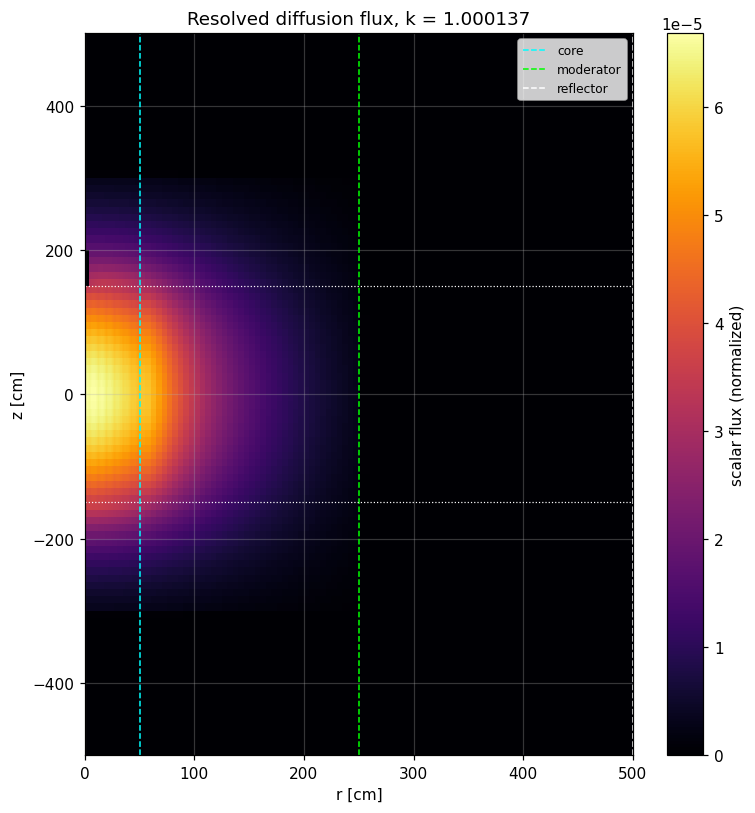

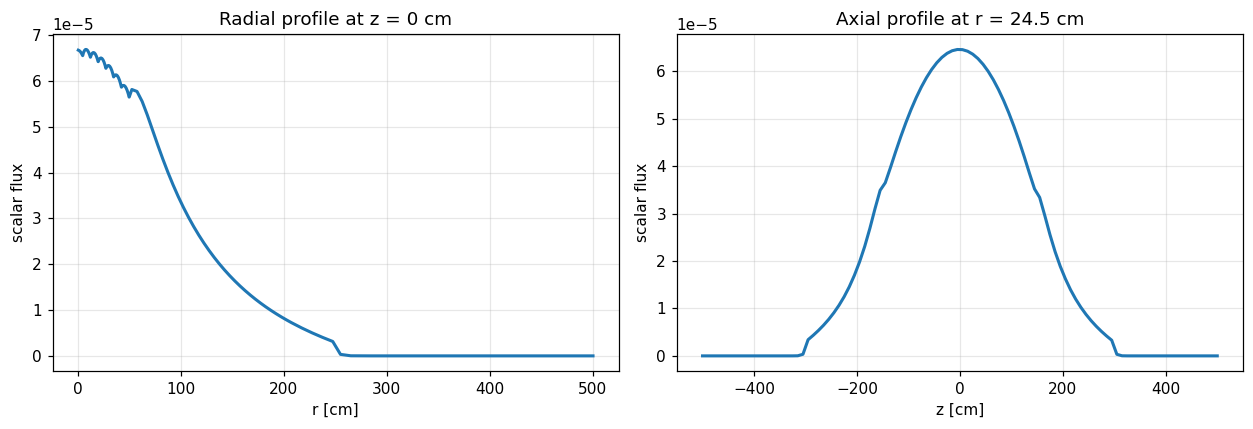

In [5]:
phi_clean = sol_clean['phi']
r_grid = sol_clean['r_grid']
z_grid = sol_clean['z_grid']

fig, ax = plt.subplots(figsize=(7.2, 7.5))
image = ax.pcolormesh(
    sol_clean['r_edges'],
    sol_clean['z_edges'],
    phi_clean.T,
    cmap='inferno',
    shading='flat',
)
for radius, color, label in (
    (geometry['core_radius_cm'], 'cyan', 'core'),
    (geometry['moderator_radius_cm'], 'lime', 'moderator'),
    (geometry['reflector_radius_cm'], 'white', 'reflector'),
):
    ax.axvline(radius, color=color, lw=1.0, ls='--', label=label)
ax.axhline(model_2d.core_height / 2, color='white', lw=0.8, ls=':')
ax.axhline(-model_2d.core_height / 2, color='white', lw=0.8, ls=':')
fig.colorbar(image, ax=ax, label='scalar flux (normalized)')
ax.set(xlabel='r [cm]', ylabel='z [cm]', title=f'Resolved diffusion flux, k = {k_diff:.6f}')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

midplane = int(np.argmin(np.abs(z_grid)))
probe = int(np.argmin(np.abs(r_grid - 0.5 * geometry['core_radius_cm'])))
fig, (ax_r, ax_z) = plt.subplots(1, 2, figsize=(11.5, 4.0))
ax_r.plot(r_grid, phi_clean[:, midplane], lw=2)
ax_r.set(xlabel='r [cm]', ylabel='scalar flux', title='Radial profile at z = 0 cm')
ax_z.plot(z_grid, phi_clean[probe, :], lw=2)
ax_z.set(xlabel='z [cm]', ylabel='scalar flux', title=f'Axial profile at r = {r_grid[probe]:.1f} cm')
plt.tight_layout()
plt.show()

## 3. CE-Referenced SPH Demonstration

The SPH fit uses the raw continuous-energy region/group flux tally. Both the OpenMC and diffusion fluxes are normalized to equal total fission production. For region `i` and group `g`, the fixed-point target is the ratio of reference flux to diffusion region-integrated flux. The update is damped in log space.

A factor multiplies absorption, fission, and all scattering sources leaving that group; the transport term is multiplied before conversion back to `D`, so the implemented diffusion coefficient is divided by the factor. `chi` is unchanged. The separate cylindrical `kappa-fission` mesh is not used to fit factors: it independently tests radial and axial power shape.

This export is suitable for demonstrating the data flow, but it is not yet a qualification reference. Its CE `k_eff` uncertainty is above 15 pcm and some low-flux region/group bins have large relative tally uncertainty. The interactive fit below excludes bins above 2% relative standard deviation and reports them explicitly.

=== CONTINUOUS-ENERGY SPH REFERENCE ===
CE k_eff uncertainty       = 59.3 pcm
Fission normalization      = 9.994352e-01
Statistically active bins = 41 / 48
Excluded region/group bins
                                   reflector, group 1:     inf%
                                   reflector, group 2:     inf%
                                   reflector, group 3:     inf%
                            core_control_rod, group 1:  15.527%
                            core_control_rod, group 2:   9.292%
                            core_control_rod, group 3:   8.093%
                            core_control_rod, group 4:   2.185%


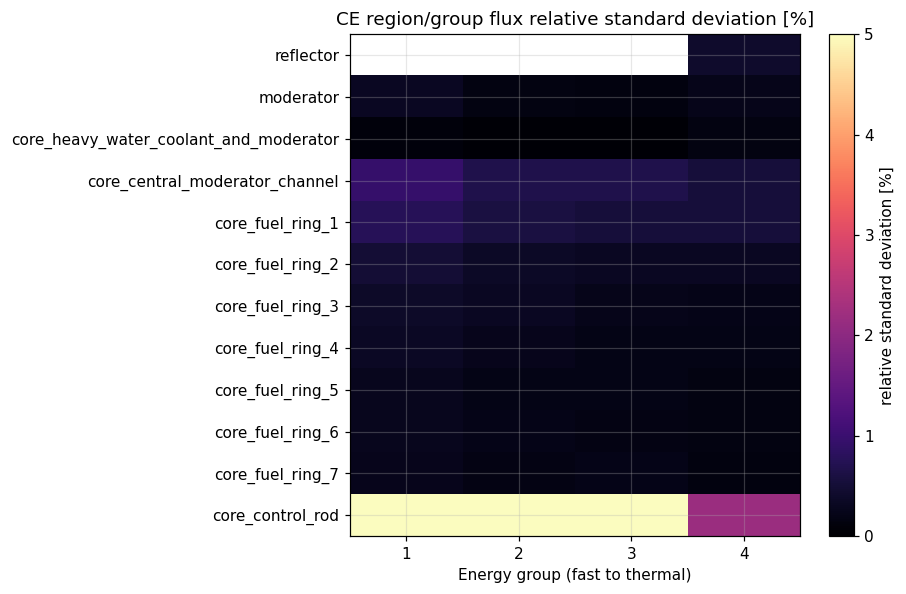

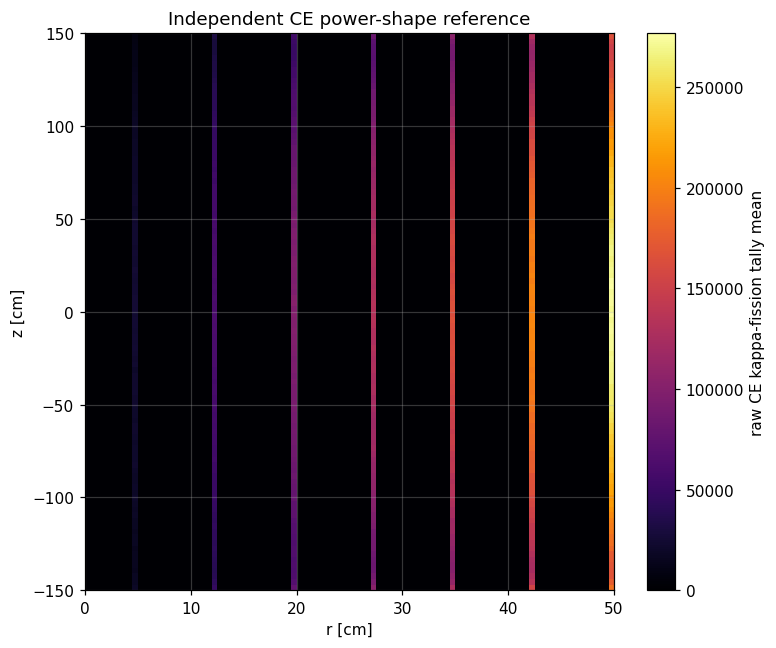

In [6]:
SPH_SETTINGS = SphSettings(
    damping=0.1,
    max_iterations=30,
    flux_tolerance=2.0e-3,
    k_stability_pcm=5.0,
    stable_iterations=2,
    maximum_relative_std_dev=0.02,
    solver_max_iterations=CACHE_SETTINGS.max_iter,
    solver_tolerance=CACHE_SETTINGS.tol,
    solver_source_tolerance=CACHE_SETTINGS.source_tol,
    solver_max_inner_iterations=CACHE_SETTINGS.max_inner_iter,
    solver_inner_tolerance=CACHE_SETTINGS.inner_tol,
)
SPH_REFERENCE = build_sph_reference(DIFFUSION_INPUT, SPH_SETTINGS)

print("=== CONTINUOUS-ENERGY SPH REFERENCE ===")
print(f"CE k_eff uncertainty       = {reference_std_pcm:.1f} pcm")
print(f"Fission normalization      = {SPH_REFERENCE.fission_production:.6e}")
print(
    f"Statistically active bins = {np.count_nonzero(SPH_REFERENCE.active)} / "
    f"{SPH_REFERENCE.active.size}"
)
print("Excluded region/group bins")
for row, label in enumerate(SPH_REFERENCE.region_labels):
    for group in range(DIFFUSION_INPUT.group_count):
        if not SPH_REFERENCE.active[row, group]:
            relative_std = 100.0 * SPH_REFERENCE.relative_std_dev[row, group]
            print(f"  {label:>42}, group {group + 1}: {relative_std:7.3f}%")

fig, ax = plt.subplots(figsize=(8.5, 5.5))
uncertainty = 100.0 * SPH_REFERENCE.relative_std_dev
image = ax.imshow(uncertainty, aspect='auto', cmap='magma', vmin=0.0, vmax=5.0)
ax.set(
    xticks=np.arange(DIFFUSION_INPUT.group_count),
    xticklabels=np.arange(1, DIFFUSION_INPUT.group_count + 1),
    yticks=np.arange(len(SPH_REFERENCE.region_labels)),
    yticklabels=SPH_REFERENCE.region_labels,
    xlabel='Energy group (fast to thermal)',
    title='CE region/group flux relative standard deviation [%]',
)
fig.colorbar(image, ax=ax, label='relative standard deviation [%]')
plt.tight_layout()
plt.show()

if power_mesh is not None:
    fig, ax = plt.subplots(figsize=(7.2, 6.0))
    image = ax.pcolormesh(
        power_mesh.r_edges_cm,
        power_mesh.z_edges_cm,
        power_mesh.mean.T,
        shading='flat',
        cmap='inferno',
    )
    fig.colorbar(image, ax=ax, label='raw CE kappa-fission tally mean')
    ax.set(xlabel='r [cm]', ylabel='z [cm]', title='Independent CE power-shape reference')
    plt.tight_layout()
    plt.show()

In [7]:
SPH_RESULT = None
SPH_FAILURE = None
try:
    SPH_RESULT = fit_sph_factors(
        DIFFUSION_INPUT,
        spacing=MESH_SPACING,
        settings=SPH_SETTINGS,
    )
except SphConvergenceError as error:
    SPH_RESULT = error.result
    SPH_FAILURE = str(error)

print("=== SPH FIXED-POINT RESULT ===")
print(f"Converged                  = {SPH_RESULT.factors.converged}")
print(f"Iterations                 = {SPH_RESULT.factors.iterations}")
print(f"Last k_eff                 = {SPH_RESULT.solution['k_eff']:.6f}")
print(f"Last CE delta-k            = {(SPH_RESULT.solution['k_eff'] - openmc_reference['keff']) * 1.0e5:+.1f} pcm")
print(f"Qualified                  = {SPH_RESULT.qualification['qualified']}")
print(f"Provisional reference      = {SPH_RESULT.qualification['provisional']}")
if SPH_FAILURE is not None:
    print(f"Status                     = {SPH_FAILURE}")
    print("The last iterate is diagnostic only; it is not a valid SPH correction.")
pprint(SPH_RESULT.qualification, sort_dicts=False)

=== SPH FIXED-POINT RESULT ===
Converged                  = False
Iterations                 = 30
Last k_eff                 = 1.008649
Last CE delta-k            = +757.1 pcm
Qualified                  = False
Provisional reference      = True
Status                     = SPH iteration did not converge within 30 iterations; last max flux error=0.144684
The last iterate is diagnostic only; it is not a valid SPH correction.
{'qualified': False,
 'provisional': True,
 'k_error_pcm': 757.0517874088356,
 'reference_keff_std_dev_pcm': 59.33564724597487,
 'maximum_region_group_flux_error': 0.14468352356486647,
 'radial_power_error': {'rms': 0.08565468409353315,
                        'maximum': 0.44471151617936117},
 'axial_power_error': {'rms': 0.045828911644453726,
                       'maximum': 0.33929535217204915},
 'thresholds': {'k_pcm': 50.0,
                'reference_keff_std_dev_pcm': 15.0,
                'region_group_flux': 0.01,
                'power_rms': 0.02,
          

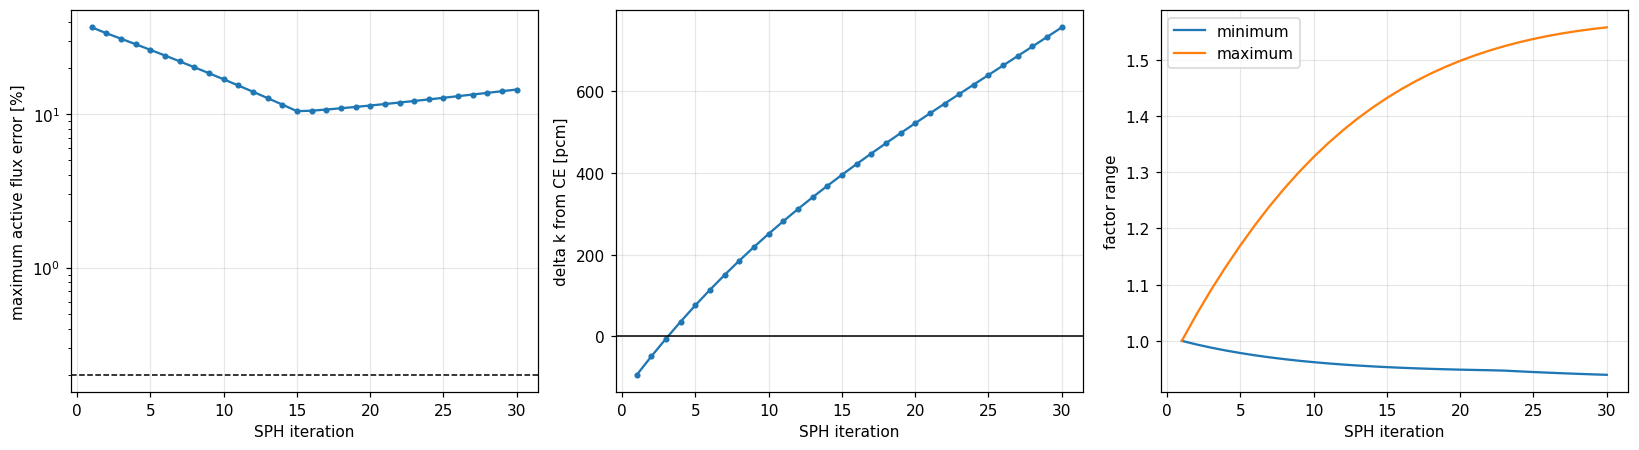

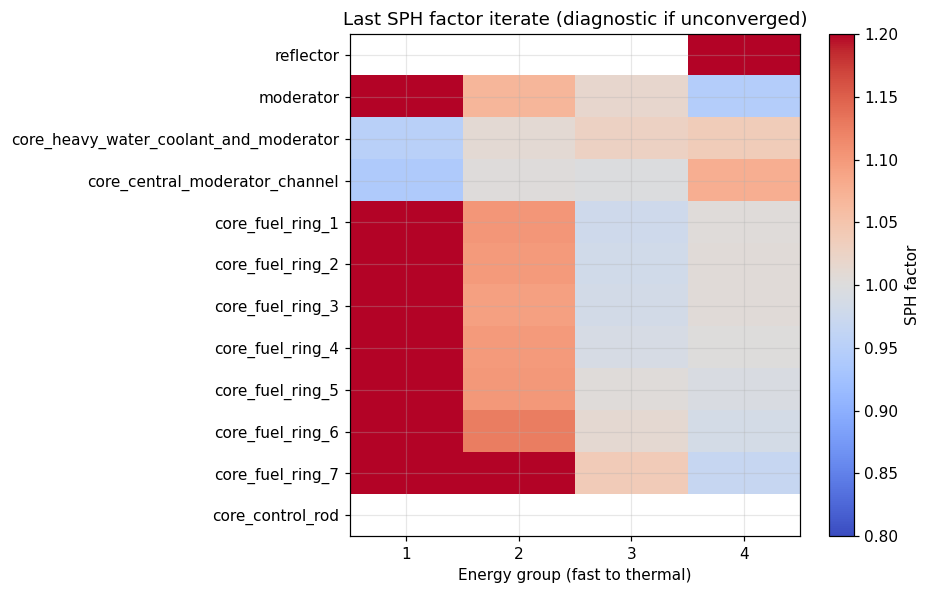

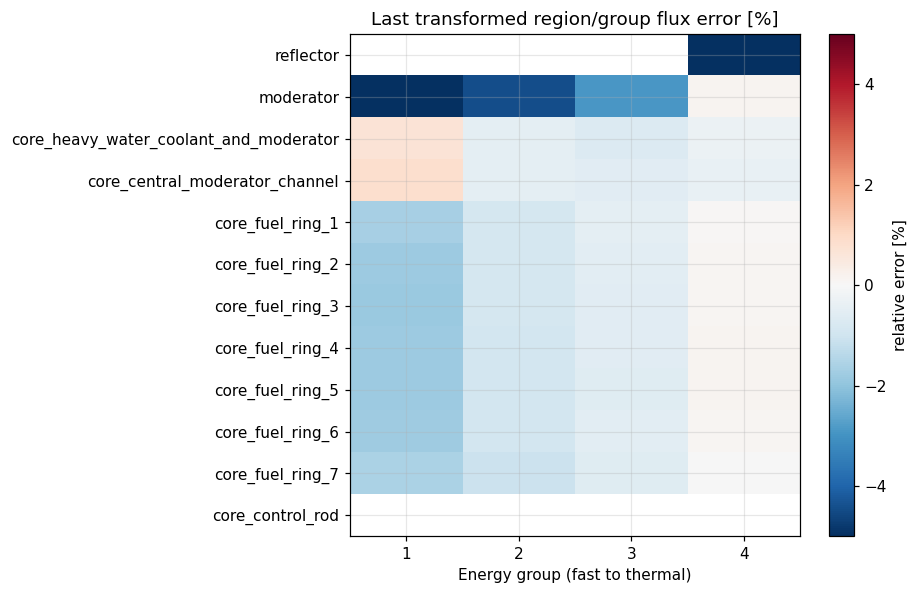

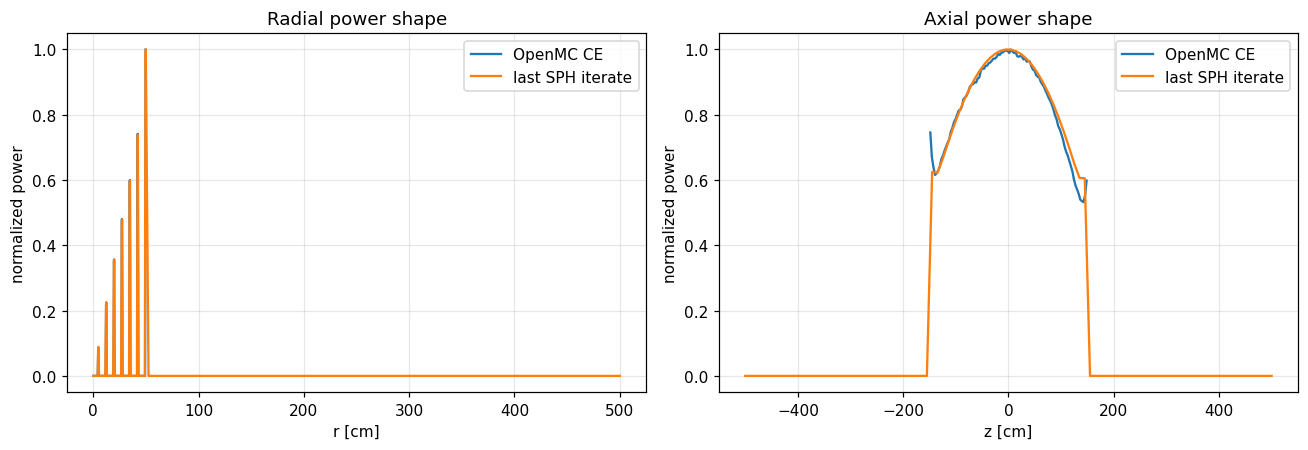

In [8]:
history = SPH_RESULT.factors.history
iterations = np.array([entry['iteration'] for entry in history])
flux_error = 100.0 * np.array([entry['max_flux_error'] for entry in history])
k_history = np.array([entry['k_eff'] for entry in history])
factor_min = np.array([entry['minimum_factor'] for entry in history])
factor_max = np.array([entry['maximum_factor'] for entry in history])

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.2))
axes[0].semilogy(iterations, flux_error, 'o-', ms=3)
axes[0].axhline(100.0 * SPH_SETTINGS.flux_tolerance, color='black', ls='--', lw=1)
axes[0].set(xlabel='SPH iteration', ylabel='maximum active flux error [%]')
axes[1].plot(iterations, (k_history - openmc_reference['keff']) * 1.0e5, 'o-', ms=3)
axes[1].axhline(0.0, color='black', lw=1)
axes[1].set(xlabel='SPH iteration', ylabel='delta k from CE [pcm]')
axes[2].plot(iterations, factor_min, label='minimum')
axes[2].plot(iterations, factor_max, label='maximum')
axes[2].set(xlabel='SPH iteration', ylabel='factor range')
axes[2].legend()
plt.tight_layout()
plt.show()

factors = SPH_RESULT.factors.factors
fig, ax = plt.subplots(figsize=(8.5, 5.5))
image = ax.imshow(
    np.where(SPH_RESULT.factors.active, factors, np.nan),
    aspect='auto',
    cmap='coolwarm',
    vmin=0.8,
    vmax=1.2,
)
ax.set(
    xticks=np.arange(DIFFUSION_INPUT.group_count),
    xticklabels=np.arange(1, DIFFUSION_INPUT.group_count + 1),
    yticks=np.arange(len(SPH_REFERENCE.region_labels)),
    yticklabels=SPH_REFERENCE.region_labels,
    xlabel='Energy group (fast to thermal)',
    title='Last SPH factor iterate (diagnostic if unconverged)',
)
fig.colorbar(image, ax=ax, label='SPH factor')
plt.tight_layout()
plt.show()

diffusion_flux = region_integrated_flux(
    SPH_RESULT.system,
    SPH_RESULT.solution,
    region_labels=SPH_REFERENCE.region_labels,
)
transformed_flux = factors * diffusion_flux
relative_error = np.full_like(transformed_flux, np.nan)
relative_error[SPH_RESULT.factors.active] = (
    transformed_flux[SPH_RESULT.factors.active]
    / SPH_REFERENCE.flux[SPH_RESULT.factors.active]
    - 1.0
)
fig, ax = plt.subplots(figsize=(8.5, 5.5))
image = ax.imshow(100.0 * relative_error, aspect='auto', cmap='RdBu_r', vmin=-5.0, vmax=5.0)
ax.set(
    xticks=np.arange(DIFFUSION_INPUT.group_count),
    xticklabels=np.arange(1, DIFFUSION_INPUT.group_count + 1),
    yticks=np.arange(len(SPH_REFERENCE.region_labels)),
    yticklabels=SPH_REFERENCE.region_labels,
    xlabel='Energy group (fast to thermal)',
    title='Last transformed region/group flux error [%]',
)
fig.colorbar(image, ax=ax, label='relative error [%]')
plt.tight_layout()
plt.show()

if power_mesh is not None:
    ce_radial = np.sum(power_mesh.mean, axis=1) / np.diff(power_mesh.r_edges_cm)
    ce_axial = np.sum(power_mesh.mean, axis=0) / np.diff(power_mesh.z_edges_cm)
    ce_radial /= np.max(ce_radial)
    ce_axial /= np.max(ce_axial)
    ce_r = 0.5 * (power_mesh.r_edges_cm[:-1] + power_mesh.r_edges_cm[1:])
    ce_z = 0.5 * (power_mesh.z_edges_cm[:-1] + power_mesh.z_edges_cm[1:])
    diffusion_power = normalized_power_profiles(SPH_RESULT.system, SPH_RESULT.solution)
    fig, (ax_r, ax_z) = plt.subplots(1, 2, figsize=(12.0, 4.2))
    ax_r.plot(ce_r, ce_radial, label='OpenMC CE')
    ax_r.plot(diffusion_power['radial_axis_cm'], diffusion_power['radial'], label='last SPH iterate')
    ax_r.set(xlabel='r [cm]', ylabel='normalized power', title='Radial power shape')
    ax_z.plot(ce_z, ce_axial, label='OpenMC CE')
    ax_z.plot(diffusion_power['axial_axis_cm'], diffusion_power['axial'], label='last SPH iterate')
    ax_z.set(xlabel='z [cm]', ylabel='normalized power', title='Axial power shape')
    ax_r.legend()
    ax_z.legend()
    plt.tight_layout()
    plt.show()

In [9]:
SPH_FACTOR_PATH = MGXS_EXPORT_DIR / 'outputs' / 'sph_factors.json'
if SPH_RESULT.factors.converged and SPH_RESULT.qualification['qualified']:
    saved_path = save_sph_factors(SPH_RESULT.factors, SPH_FACTOR_PATH)
    SPH_PREPARED = prepare_concentric_diffusion_cache(
        DIFFUSION_INPUT,
        settings=CACHE_SETTINGS,
        sph_factors=SPH_RESULT.factors,
    )
    print(f"Qualified factors saved   = {saved_path}")
    print(f"Corrected cache directory = {SPH_PREPARED.cache_dir}")
else:
    print("No SPH artifact or corrected production cache was written.")
    print("Persistence requires convergence and all qualification thresholds.")

No SPH artifact or corrected production cache was written.
Persistence requires convergence and all qualification thresholds.


## 4. Exploratory Equivalent Rod Scan

This calculation adds a scalar absorption increment inside the physical rod radius. It does not use rodded OpenMC MGXS, SPH factors, or a transport calibration, and is excluded from the clean-core acceptance criteria.

In [ ]:
scan = scan_multigroup_rod_worth_2d(
    model_2d,
    x_values=np.linspace(0.0, 1.0, 5),
    mesh=mesh,
    clean_solution=sol_clean,
    max_iter=CACHE_SETTINGS.max_iter,
    tol=CACHE_SETTINGS.tol,
    source_tol=CACHE_SETTINGS.source_tol,
    max_inner_iter=CACHE_SETTINGS.max_inner_iter,
    inner_tol=CACHE_SETTINGS.inner_tol,
    warm_start=True,
)
if not np.isclose(scan['k_eff'][0], k_diff, rtol=0.0, atol=5.0e-5):
    raise RuntimeError('Rod scan zero-insertion state differs from the clean solve')

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(scan['x_insert'] * 100, scan['delta_rho_pcm'], 'o-', lw=2, label='equivalent rod worth')
ax.plot(scan['x_insert'] * 100, scan['rho_total_pcm'], 's--', lw=1.5, label='total reactivity')
ax.axhline(0.0, color='black', lw=0.7)
ax.set(xlabel='Rod insertion [%]', ylabel='Reactivity [pcm]', title='Exploratory uncalibrated rod scan')
ax.legend()
plt.tight_layout()
plt.show()

print("=== EXPLORATORY ROD SCAN ===")
print("Not transport-calibrated; excluded from validation.")
print(f"Full-insertion equivalent worth = {scan['delta_rho_pcm'][-1]:+.1f} pcm")
print(f"Full-insertion total rho        = {scan['rho_total_pcm'][-1]:+.1f} pcm")

## 5. Interpretation

The workflow has one canonical diffusion path: resolved XML regions, selectable group count, transport-derived diffusion coefficients, uncorrected non-`nu` P0 scattering, per-group sparse spatial operators, and a persistent prepared cache.

The SPH chapter is deliberately fail-closed. Region/group fluxes drive the iteration, the power mesh independently checks shape, and factors enter the production cache only after convergence and qualification. With the present low-statistics reference, non-convergence or a provisional result is evidence that the fitter or reference must be improved, not permission to tune factors to force `k_eff`. The exploratory rod model still requires rodded MGXS before it can become a validation target.